# LOGISTIC REGRESSION – COMPLETE RESEARCH TRACK

# Step 1 — Dataset Selection


In [1]:
import pandas as pd
import numpy as np

In [2]:
#loading dataset
df=pd.read_csv('/content/student_placement_synthetic.csv')

In [3]:
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [4]:
df.tail()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3,0,NaN
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0,1,16.58
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2,1,17.24
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1,1,17.01
99999,ECE,Tier-1,7.00,0,2.8,5.3,64.5,5.7,5.7,3.4,0,2,2,2,0,1,1,14.98


In [5]:
df.sample()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
84011,CSE,Tier-3,6.0,1,6.4,8.7,52.5,4.7,4.9,4.7,0,1,4,0,0,0,0,NaN


# Step 2 — Data Understanding & Problem Framing

**1. Real-World Context**

Industry / Domain

This dataset belongs to the Education Technology (EdTech) and Recruitment Analytics domain. It represents student academic performance, technical skills, and extracurricular activities that influence campus placement outcomes in Indian engineering colleges.

**Decision Problem**

Universities and training institutions want to identify students who are likely to get placed during campus recruitment.
The problem is to predict the probability of a student getting placed based on their academic profile, skills, and activities.

Such predictions can help institutions improve training programs and placement preparation strategies.

**2. Prediction Task**

What are we predicting?

The model predicts:  *placement_status*

Value	Meaning
* 1	Student is placed
* 0	Student is not placed

Therefore, the model estimates the probability that a student will get placed based on the available features.

**Type of Machine Learning Problem**

This is a Binary Classification Problem because the target variable has two possible outcomes:

* Placed
* Not placed

Logistic Regression is an appropriate algorithm for such problems since it predicts probabilities of binary outcomes.

**3. Why This Prediction Matters**

Business / Societal Value

Predicting placement outcomes provides value in several ways:

* Colleges can identify students at risk of not getting placed and provide early intervention training.

* Placement cells can improve recruitment preparation strategies.

* Students can understand which skills influence employability.

* EdTech platforms can design targeted training programs.

Overall, this helps increase employability rates and improve career outcomes for students.

**Cost of Wrong Predictions**

| Prediction Type | Meaning                                                                | Impact                                                                             |
| --------------- | ---------------------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| False Positive  | Model predicts student will be placed but they are not                 | Students may not receive additional training, reducing their chances of employment |
| False Negative  | Model predicts student will not be placed but they actually get placed | Student may receive unnecessary training or intervention                           |

In this scenario, False Negatives are usually more costly, because students who actually need help may be overlooked.

**4. Stakeholders**

Who Would Use This Model?

* University Placement Cells
* Career Counselors
* EdTech Training Platforms
* College Administration

How They Would Use It

* The model could be used to:
* Identify students at risk of not getting placed
* Provide personalized training programs
* Improve placement preparation strategies
* Analyze which skills most influence employability

In [5]:
df.shape

(100000, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [7]:
df.describe()

,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,68475.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750,17.308014
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618,2.601041
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,6.880000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,15.530000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000,17.250000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000,19.040000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000,28.330000


**Dataset Summary Report**

*1. Number of Rows and Columns*
* Number of Rows : **100,000**
* Number of Columns : **18**      


*2. Target Variable*

Target Variable: **placement_status**

Justification:

placement_status is selected as the target variable because it represents the final outcome of the campus recruitment process. All other features such as CGPA, coding skills, internships, and projects act as predictor variables that influence whether a student gets placed or not.

Therefore, the goal of the model is to predict the probability that a student will be placed based on their academic and skill profile.

*3. Class Distribution (Check Imbalance)*
| Class          | Count  | Percentage |
| -------------- | ------ | ---------- |
| Placed (1)     | 68,475 | 68.5%      |
| Not Placed (0) | 31,525 | 31.5%      |

The dataset shows moderate class imbalance, with more students being placed than not placed. Although the imbalance is not extremely severe, it should still be monitored during model training because it can influence model performance and bias predictions toward the majority class.

*4. Feature Types*

Total Numerical Features: 15
| Feature                   | Description                                    | Data Type |
| ------------------------- | ---------------------------------------------- | --------- |
| cgpa                      | Cumulative GPA on a 10-point scale             | Float     |
| backlogs                  | Number of failed subjects                      | Integer   |
| coding_skills             | Coding ability score (1–10)                    | Float     |
| dsa_score                 | Data Structures & Algorithms proficiency score | Float     |
| aptitude_score            | Aptitude test percentile score                 | Float     |
| communication_skills      | Communication ability score (1–10)             | Float     |
| ml_knowledge              | Machine Learning knowledge score               | Float     |
| system_design             | System design ability score                    | Float     |
| internships               | Number of internships completed                | Integer   |
| projects_count            | Number of academic/technical projects          | Integer   |
| certifications            | Number of certifications obtained              | Integer   |
| hackathons                | Number of hackathons participated              | Integer   |
| open_source_contributions | Open source contributions count                | Integer   |
| extracurriculars          | Participation in extracurricular activities    | Integer   |
| salary_package_lpa        | Salary offered in Lakhs Per Annum              | Float     |

Total Categorical Features: 2

| Feature      | Description                                             | Data Type |
| ------------ | ------------------------------------------------------- | --------- |
| branch       | Engineering branch (CSE, ECE, ME, CE, EE, IT, Chemical) | Object    |
| college_tier | Tier level of the college (Tier-1, Tier-2, Tier-3)      | Object    |

Ordinal 1
| Feature        | Order / Meaning                        |
| -------------- | -------------------------------------- |
| college_tier   | Tier-1 > Tier-2 > Tier-3               |
| internships    | 0 → 3 (increasing experience)          |
| projects_count | 0 → 5 (increasing project experience)  |
| certifications | 0 → 4 (increasing certification level) |


*5. Initial Data Quality Issues*

Based on the dataset inspection:

* No missing values in most predictor variables
* One variable contains missing values (salary_package_lpa)
* Mix of categorical and numerical features requiring encoding
* Some features have limited ranges and discrete values

Overall, the dataset is clean and well-structured, but preprocessing is still required before modeling.

*6. Missing Values Pattern*

Column	Missing Values: salary_package_lpa	31,525

The column salary_package_lpa contains missing values because salary is only available for students who were placed.

Thus:

Placed students → salary value exists

Not placed students → salary = NaN

This missing pattern is logical and expected, not a data error.

For the placement prediction task, this variable should be removed or handled carefully to prevent information leakage.

*7. Class Imbalance Severity*

The class distribution is:

* Placed: 68.5%
* Not Placed: 31.5%

This represents moderate imbalance, but not extreme.

Potential approaches if needed:

* Stratified train-test split
* Class weighting in Logistic Regression

Evaluation using precision, recall, and F1-score instead of only accuracy

*8. Skewness in Numerical Variables*

Several numerical variables are likely to show right-skewed distributions, particularly those representing counts or limited ranges.

Examples:

* internships
* certifications
* hackathons
* open_source_contributions
* extracurriculars

These variables may contain many zero values and fewer high values, creating skewed distributions. Other variables like CGPA, coding skills, and aptitude score are likely to follow approximately normal distributions.

*9. Potential Data Leakage Signals*

One feature presents a clear data leakage risk:  salary_package_lpa

Reason:

* Salary is assigned only after a student gets placed.
* If this variable is used to predict placement_status, the model would indirectly know whether the student was placed.
* This would cause information leakage, leading to artificially high model performance.

Therefore: salary_package_lpa must be excluded when predicting placement_status.

# Step 3 — Data Preprocessing

##  **1. Missing values**

In [8]:
# missing values
df.isnull().sum()

,0
branch,0
college_tier,0
cgpa,0
backlogs,0
coding_skills,0
dsa_score,0
aptitude_score,0
communication_skills,0
ml_knowledge,0
system_design,0


In [9]:
#missing percentage
(df.isnull().sum()/len(df))*100

,0
branch,0.000
college_tier,0.000
cgpa,0.000
backlogs,0.000
coding_skills,0.000
dsa_score,0.000
aptitude_score,0.000
communication_skills,0.000
ml_knowledge,0.000
system_design,0.000


<Axes: >

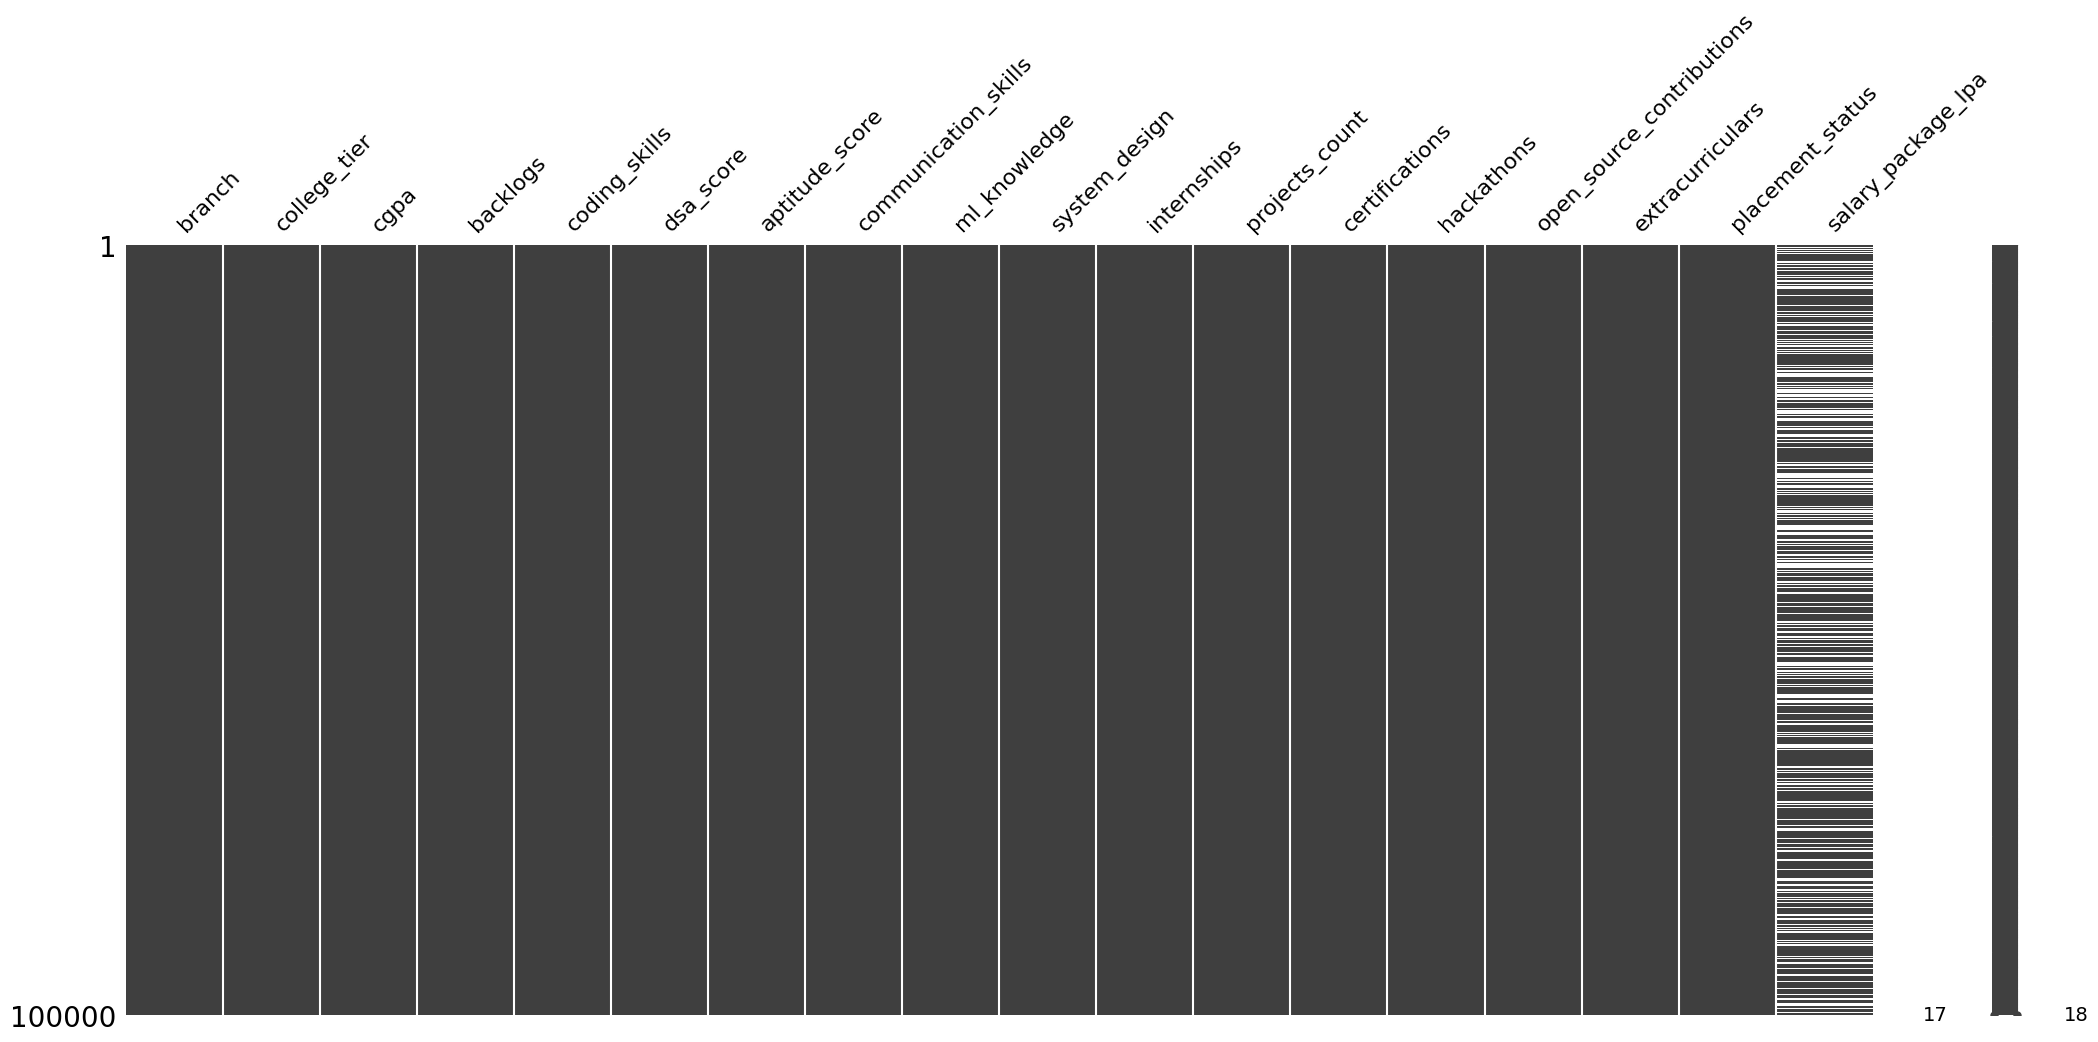

In [10]:
import missingno as msno
msno.matrix(df)

**Observations**

These missing values occur because salary is recorded only for students who were placed. Students who were not placed have NaN salary values, which is logically correct.

Since the goal of this model is to predict placement_status, the salary variable represents future information and therefore introduces data leakage if used as a predictor.

In [11]:
#  Analyze Missingness Pattern
df.groupby("placement_status")["salary_package_lpa"].count()

,salary_package_lpa
placement_status,
0,0
1,68475


**Observation**

Salary values exist only when placement_status = 1.
For non-placed students the salary is missing, indicating Missing Not At Random (MNAR).

**Comparison of removal vs Imputation**

In [19]:
# Method 1: Drop salary column
df_drop = df.drop("salary_package_lpa", axis=1)

# Method 2: Zero Imputation
df_zero = df.copy()
df_zero["salary_package_lpa"] = df_zero["salary_package_lpa"].fillna(0)

In [20]:
df_drop = pd.get_dummies(df_drop, columns=["branch","college_tier"], drop_first=True)
df_zero = pd.get_dummies(df_zero, columns=["branch","college_tier"], drop_first=True)

In [21]:
X_drop = df_drop.drop("placement_status", axis=1)
y_drop = df_drop["placement_status"]

X_zero = df_zero.drop("placement_status", axis=1)
y_zero = df_zero["placement_status"]

In [22]:
from sklearn.model_selection import train_test_split

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_drop, y_drop, test_size=0.2, random_state=42
)

X_train_z, X_test_z, y_train_z, y_test_z = train_test_split(
    X_zero, y_zero, test_size=0.2, random_state=42
)

In [23]:
from sklearn.linear_model import LogisticRegression

model_drop = LogisticRegression(max_iter=1000)
model_zero = LogisticRegression(max_iter=1000)

model_drop.fit(X_train_d, y_train_d)
model_zero.fit(X_train_z, y_train_z)

LogisticRegression(max_iter=1000)

In [24]:
y_pred_drop = model_drop.predict(X_test_d)
y_pred_zero = model_zero.predict(X_test_z)

In [25]:
from sklearn.metrics import accuracy_score, classification_report

print("DROP METHOD RESULTS")
print("Accuracy:", accuracy_score(y_test_d, y_pred_drop))
print(classification_report(y_test_d, y_pred_drop))

print("ZERO IMPUTATION RESULTS")
print("Accuracy:", accuracy_score(y_test_z, y_pred_zero))
print(classification_report(y_test_z, y_pred_zero))

DROP METHOD RESULTS
Accuracy: 0.6994
              precision    recall  f1-score   support

           0       0.57      0.20      0.30      6335
           1       0.72      0.93      0.81     13665

    accuracy                           0.70     20000
   macro avg       0.64      0.57      0.55     20000
weighted avg       0.67      0.70      0.65     20000

ZERO IMPUTATION RESULTS
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6335
           1       1.00      1.00      1.00     13665

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



**Common Conclusion (Missing Value Handling Comparison)**

Two preprocessing strategies were evaluated to handle the missing values in the salary_package_lpa variable: dropping the column and zero imputation. When the salary column was removed, the Logistic Regression model achieved an accuracy of approximately 70%, indicating that the model relied on meaningful predictors such as CGPA, skills, internships, and other student attributes to predict placement outcomes. Although the accuracy was moderate, it reflects a realistic prediction scenario.

In contrast, when missing salary values were replaced with 0, the model achieved 100% accuracy with perfect precision, recall, and F1-scores. This occurs because salary is directly linked to placement status: students who are placed receive a salary, while non-placed students effectively have zero salary. As a result, the model learns a direct relationship between salary and placement, leading to data leakage and artificially perfect performance.

Therefore, despite the higher accuracy obtained with zero imputation, the results are misleading and not suitable for real-world prediction. Removing the salary_package_lpa variable prevents leakage and ensures that the model learns genuine relationships between student characteristics and placement outcomes. Hence, dropping the salary column is the more appropriate and reliable preprocessing strategy for placement prediction.

##  **2. Duplicates**

In [26]:
# Check number of duplicate rows
df.duplicated().sum()

np.int64(0)

**Conclusion**

Duplicate checking confirmed that the dataset contained only unique observations, ensuring that the model learning process is not biased by repeated data points. Therefore, no preprocessing action was required, and the model performance remained unaffected.

##  **3. Outlier detection**

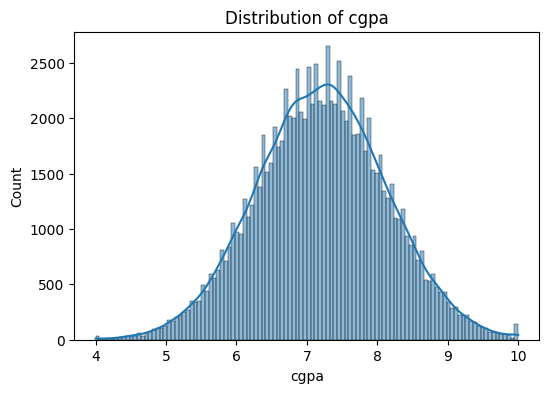

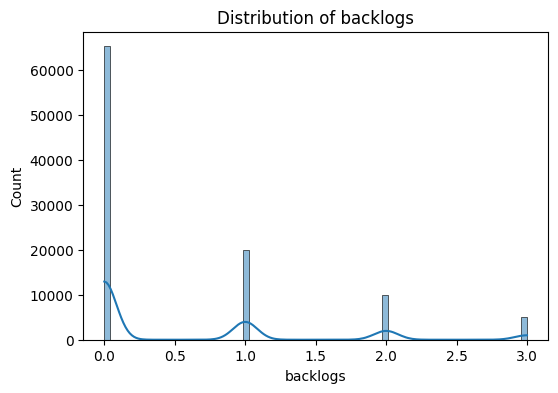

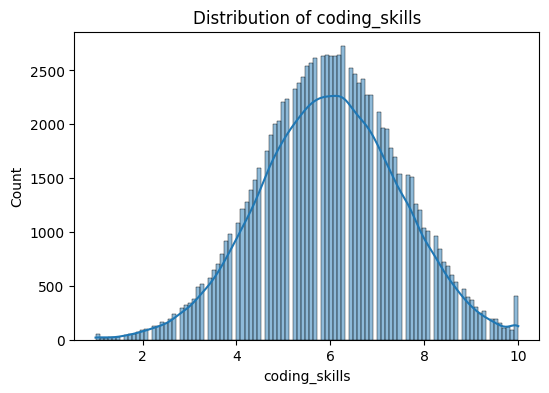

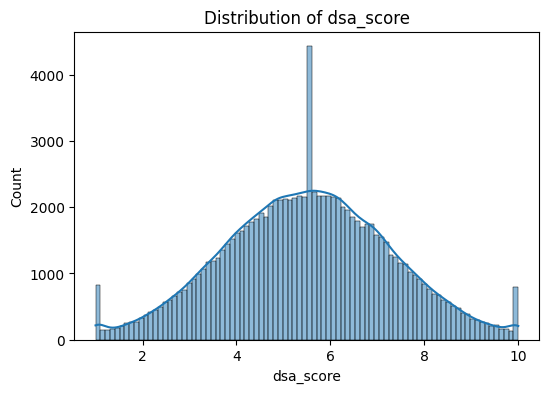

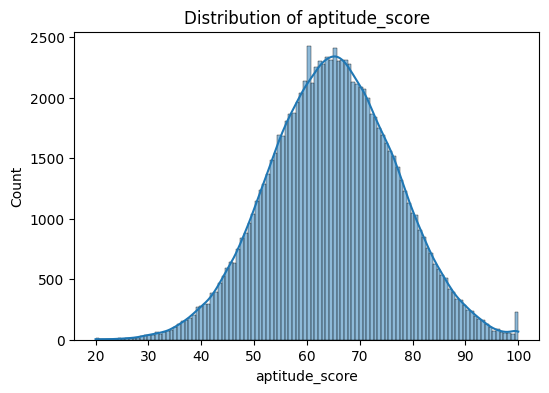

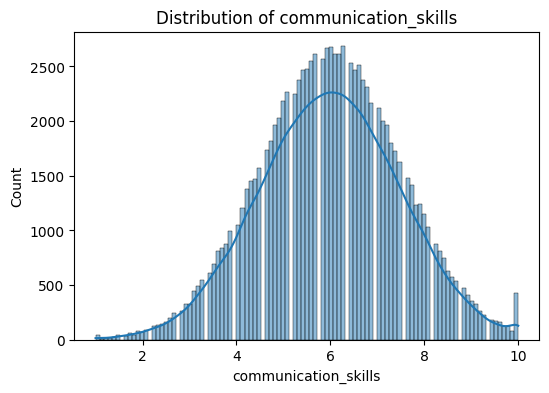

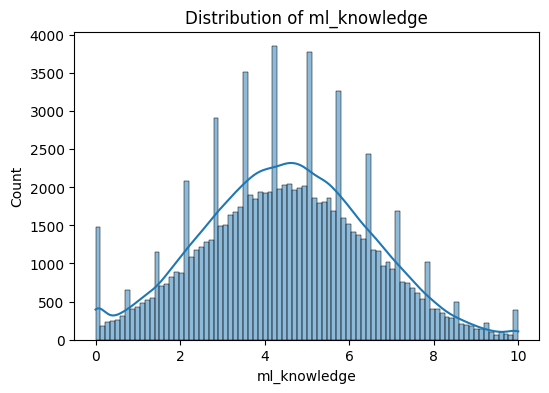

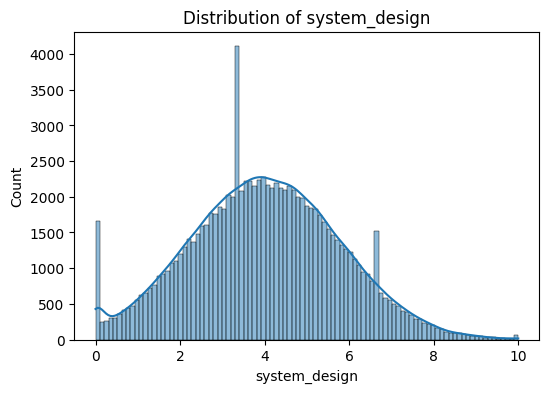

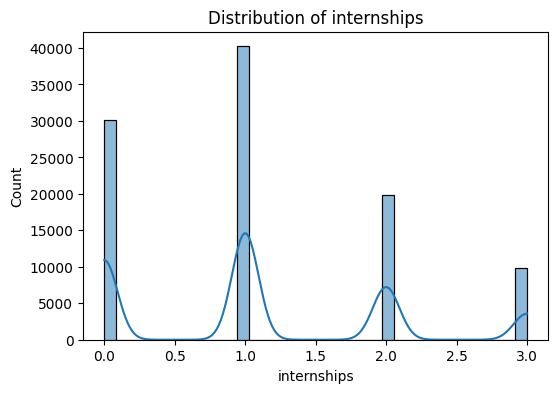

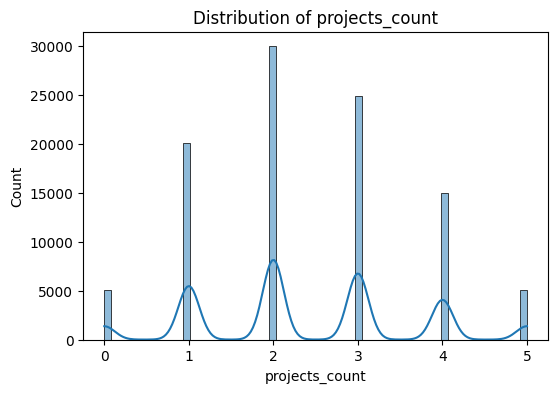

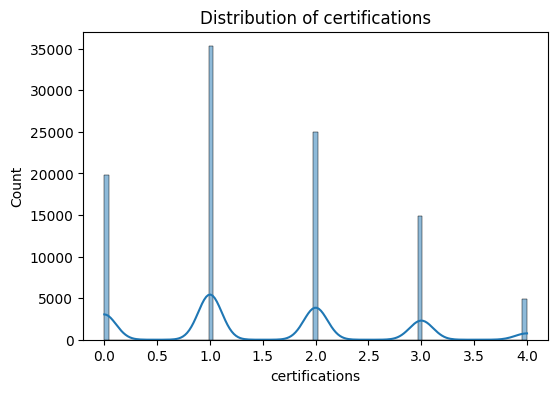

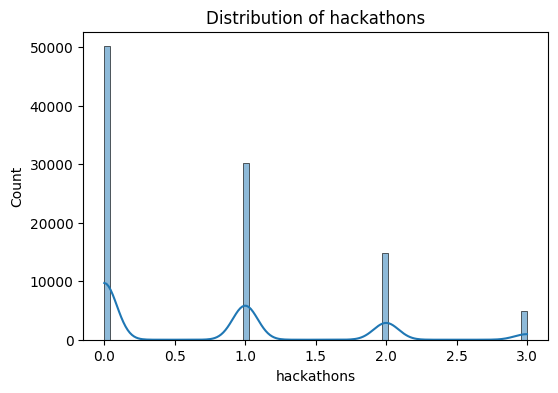

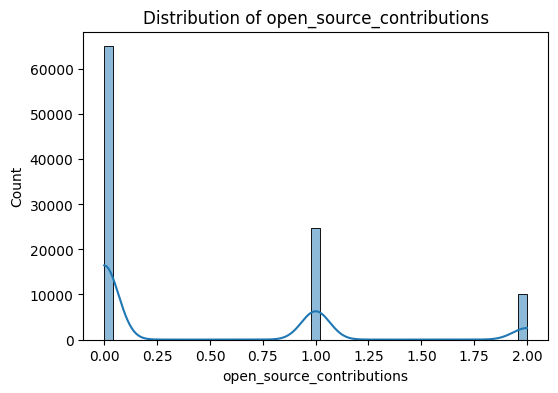

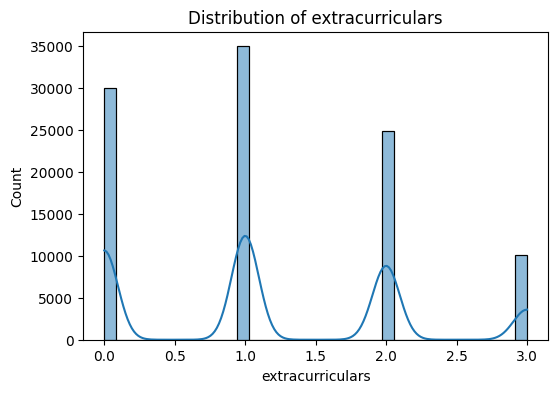

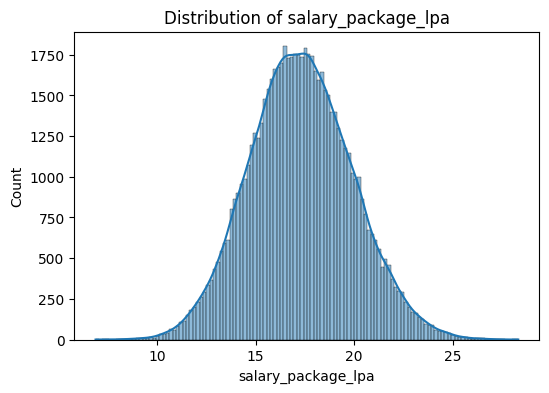

In [46]:
#dist plot of numeric variables
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = ['cgpa','backlogs','coding_skills', 'dsa_score','aptitude_score','communication_skills','ml_knowledge','system_design','internships','projects_count',
 'certifications','hackathons','open_source_contributions','extracurriculars','salary_package_lpa']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [27]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score',
       'communication_skills', 'ml_knowledge', 'system_design', 'internships',
       'projects_count', 'certifications', 'hackathons',
       'open_source_contributions', 'extracurriculars', 'placement_status',
       'salary_package_lpa'],
      dtype='object')

In [28]:
outliers = {}

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    outliers[col] = count

outliers

{'cgpa': 686,
 'backlogs': 4981,
 'coding_skills': 382,
 'dsa_score': 0,
 'aptitude_score': 680,
 'communication_skills': 362,
 'ml_knowledge': 332,
 'system_design': 364,
 'internships': 0,
 'projects_count': 0,
 'certifications': 4946,
 'hackathons': 4916,
 'open_source_contributions': 0,
 'extracurriculars': 0,
 'placement_status': 0,
 'salary_package_lpa': 459}

In [29]:
total_outliers = sum(outliers.values())
print("Total Outliers Detected:", total_outliers)

Total Outliers Detected: 18108


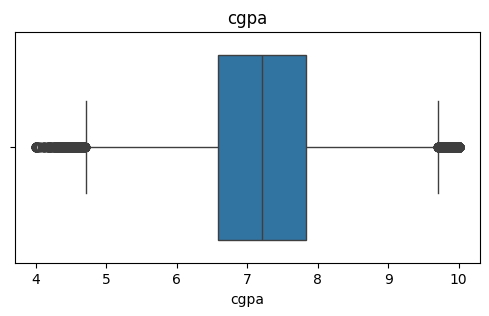

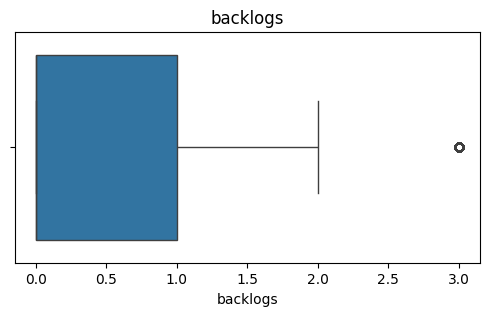

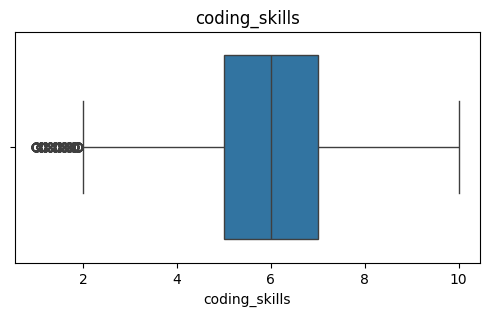

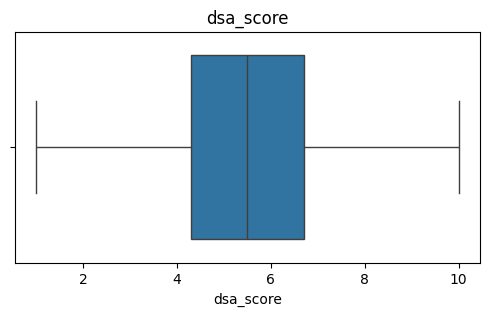

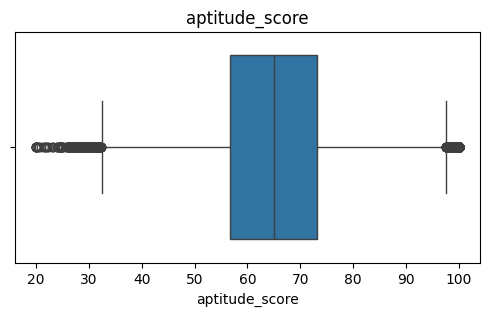

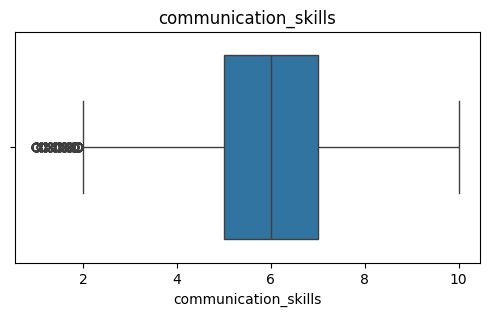

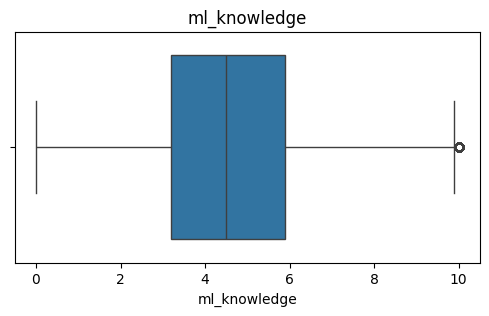

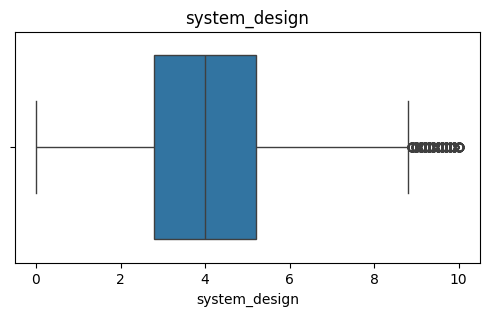

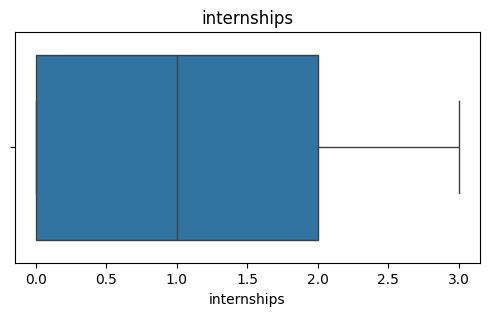

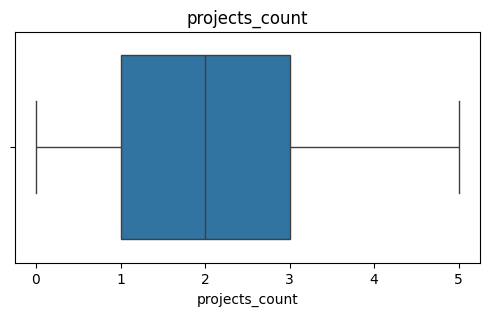

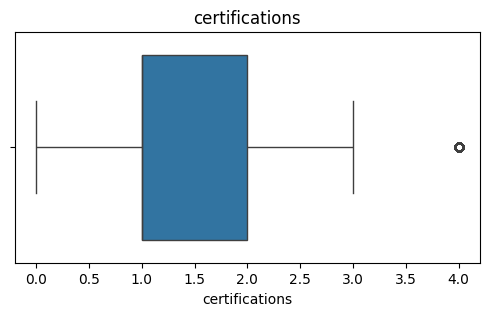

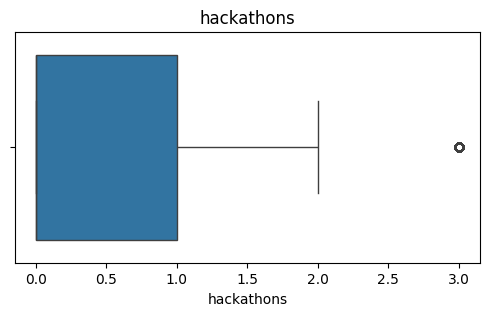

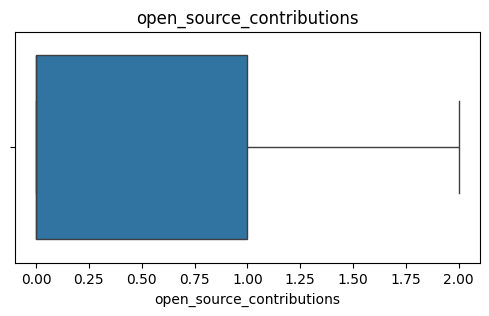

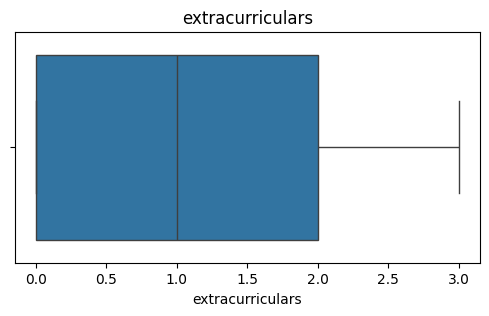

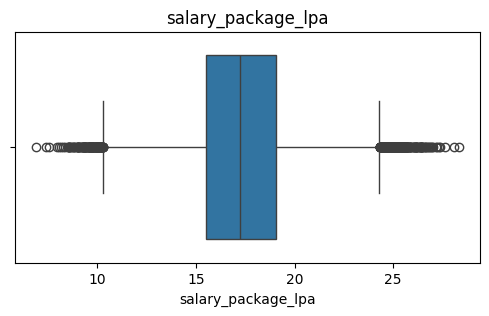

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

**Findings:**

Outlier detection was performed using the IQR (Interquartile Range) method because the dataset contains multiple numerical features and the distributions are not strictly normal. The IQR method is robust to skewed data and effectively identifies extreme observations. Boxplots were also used to visually validate the presence of outliers.

**Comparison with and without outliers**

In [30]:
df_model = df.drop(columns=["salary_package_lpa"])

In [31]:
df_encoded = pd.get_dummies(df_model, columns=["branch", "college_tier"], drop_first=True)

Logistic Regression requires numeric inputs, so categorical variables are converted using One-Hot Encoding.

In [32]:
X = df_encoded.drop("placement_status", axis=1)
y = df_encoded["placement_status"]


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_with_outliers = LogisticRegression(max_iter=1000)

model_with_outliers.fit(X_train, y_train)

y_pred_outliers = model_with_outliers.predict(X_test)

print("MODEL WITH OUTLIERS")
print("Accuracy:", accuracy_score(y_test, y_pred_outliers))
print(classification_report(y_test, y_pred_outliers))

MODEL WITH OUTLIERS
Accuracy: 0.6994
              precision    recall  f1-score   support

           0       0.57      0.20      0.30      6335
           1       0.72      0.93      0.81     13665

    accuracy                           0.70     20000
   macro avg       0.64      0.57      0.55     20000
weighted avg       0.67      0.70      0.65     20000



In [34]:
import numpy as np

df_no_outliers = df_model.copy()

numerical_cols = df_no_outliers.select_dtypes(include=np.number).columns
numerical_cols = numerical_cols.drop("placement_status")

for col in numerical_cols:

    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower) &
        (df_no_outliers[col] <= upper)
    ]

In [35]:
df_no_outliers_encoded = pd.get_dummies(
    df_no_outliers, columns=["branch", "college_tier"], drop_first=True
)

X_clean = df_no_outliers_encoded.drop("placement_status", axis=1)
y_clean = df_no_outliers_encoded["placement_status"]

In [36]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

model_without_outliers = LogisticRegression(max_iter=1000)

model_without_outliers.fit(X_train_c, y_train_c)

y_pred_clean = model_without_outliers.predict(X_test_c)

print("MODEL WITHOUT OUTLIERS")
print("Accuracy:", accuracy_score(y_test_c, y_pred_clean))
print(classification_report(y_test_c, y_pred_clean))

MODEL WITHOUT OUTLIERS
Accuracy: 0.6980533093740641
              precision    recall  f1-score   support

           0       0.57      0.19      0.29      5282
           1       0.71      0.93      0.81     11413

    accuracy                           0.70     16695
   macro avg       0.64      0.56      0.55     16695
weighted avg       0.67      0.70      0.64     16695



**Findings**

The Logistic Regression model was trained on the dataset **with outliers** and **after removing outliers using the IQR method** to evaluate the impact of extreme values on model performance.

The results show that the **accuracy of both models is nearly identical (around 70%)**, indicating that the presence of outliers does not significantly affect the predictive performance of the model. Other evaluation metrics such as **precision, recall, and F1-score** also remain very similar in both cases.

This suggests that the detected outliers are **not erroneous values but realistic variations** in student academic performance and skill levels. Additionally, Logistic Regression is generally **less sensitive to moderate outliers**, especially when the feature ranges are bounded, as in this dataset.

Overall, removing outliers did **not produce a meaningful improvement in model performance**, and therefore retaining the original dataset with outliers is acceptable for further modeling and analysis.


## **4. Categorical encoding**

Chosen Method: **One-Hot Encoding**

In this dataset, One-Hot Encoding was used for the categorical variables:

branch

college_tier

This method converts each category into a separate binary column, allowing the Logistic Regression model to treat each category independently without assuming any ordinal relationship.

**Why Encoding Choice Matters in Logistic Regression**

Logistic Regression requires numerical inputs. If categorical variables are not encoded properly, the algorithm cannot process them.

Using Label Encoding for non-ordered categories can create false numerical relationships, which may mislead the model. One-Hot Encoding avoids this issue by representing categories as independent binary variables.

**Impact on Interpretability**

One-Hot Encoding improves interpretability because each coefficient in the model represents the effect of a specific category on the probability of placement. For example, the coefficient for branch_CSE indicates how being in the CSE branch influences the likelihood of getting placed compared to the baseline branch.

**Risk of Dummy Variable Trap**

When applying One-Hot Encoding, creating binary columns for all categories can cause multicollinearity, known as the dummy variable trap. This occurs when one category can be perfectly predicted from the others.

In [43]:
categorical_cols = ["branch", "college_tier"]

In [44]:
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

## **5. Feature scaling**  Zscore

1️⃣ Why Feature Scaling is Important for Logistic Regression

Feature scaling is important because Logistic Regression is an optimization-based algorithm that uses gradient descent to estimate model coefficients.

If features are on different scales, variables with larger numerical ranges can dominate the learning process. For example, aptitude_score ranges from 20–100, while cgpa ranges from 4–10. Without scaling, the algorithm may give more importance to variables with larger magnitudes.

Scaling ensures that all numerical variables contribute equally during model training, improving the stability and interpretability of the model.

2️⃣ Effect on Gradient Convergence

Standardization helps the optimization algorithm converge faster and more efficiently. When variables are on similar scales, the gradient descent process moves more smoothly toward the optimal coefficients. Without scaling, the optimization path may become irregular, causing slower convergence or unstable updates.

In [37]:
X = df_encoded.drop("placement_status", axis=1)
y = df_encoded["placement_status"]

In [38]:
from sklearn.linear_model import LogisticRegression

model_unscaled = LogisticRegression(max_iter=1000)
model_unscaled.fit(X_train, y_train)

coeff_unscaled = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient_Unscaled": model_unscaled.coef_[0]
})

coeff_unscaled.head()

,Feature,Coefficient_Unscaled
0,cgpa,0.299244
1,backlogs,-0.152685
2,coding_skills,0.135816
3,dsa_score,0.111725
4,aptitude_score,0.009188


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)

coeff_scaled = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient_Scaled": model_scaled.coef_[0]
})

coeff_scaled.head()

,Feature,Coefficient_Scaled
0,cgpa,0.276233
1,backlogs,-0.131500
2,coding_skills,0.202852
3,dsa_score,0.198751
4,aptitude_score,0.109865


In [42]:
coeff_comparison = coeff_unscaled.merge(
    coeff_scaled, on="Feature"
)

coeff_comparison.sort_values(by="Coefficient_Scaled", ascending=False).head(10)

,Feature,Coefficient_Unscaled,Coefficient_Scaled
0,cgpa,0.299244,0.276233
8,internships,0.248265,0.233320
2,coding_skills,0.135816,0.202852
3,dsa_score,0.111725,0.198751
9,projects_count,0.129514,0.160805
14,branch_CSE,0.342163,0.147906
10,certifications,0.125152,0.139129
5,communication_skills,0.086194,0.128726
18,branch_IT,0.301689,0.110030
4,aptitude_score,0.009188,0.109865


**Common Findings**

The comparison of coefficients before and after feature scaling shows that **standardization improves the interpretability of the Logistic Regression model**. Before scaling, the magnitude of coefficients was influenced by the different ranges of the variables. Features with larger numerical ranges tended to have smaller coefficients, which made direct comparison between variables difficult.

After applying standardization, the coefficients became **more balanced and comparable**, allowing a clearer understanding of which features contribute more strongly to the prediction of placement status. Variables such as **cgpa, internships, coding_skills, and dsa_score** show relatively higher coefficients after scaling, indicating that academic performance, technical skills, and practical experience are important factors influencing placement outcomes.

Additionally, the coefficient of **aptitude_score increased noticeably after scaling**, suggesting that its effect on the model was previously underestimated due to its larger numerical range. This demonstrates how scaling ensures that all features contribute proportionally during model training.

Overall, feature scaling helps the Logistic Regression algorithm achieve **more stable optimization and meaningful coefficient interpretation**, making it easier to identify the key predictors affecting student placement.


## **6. Multicollinearity**

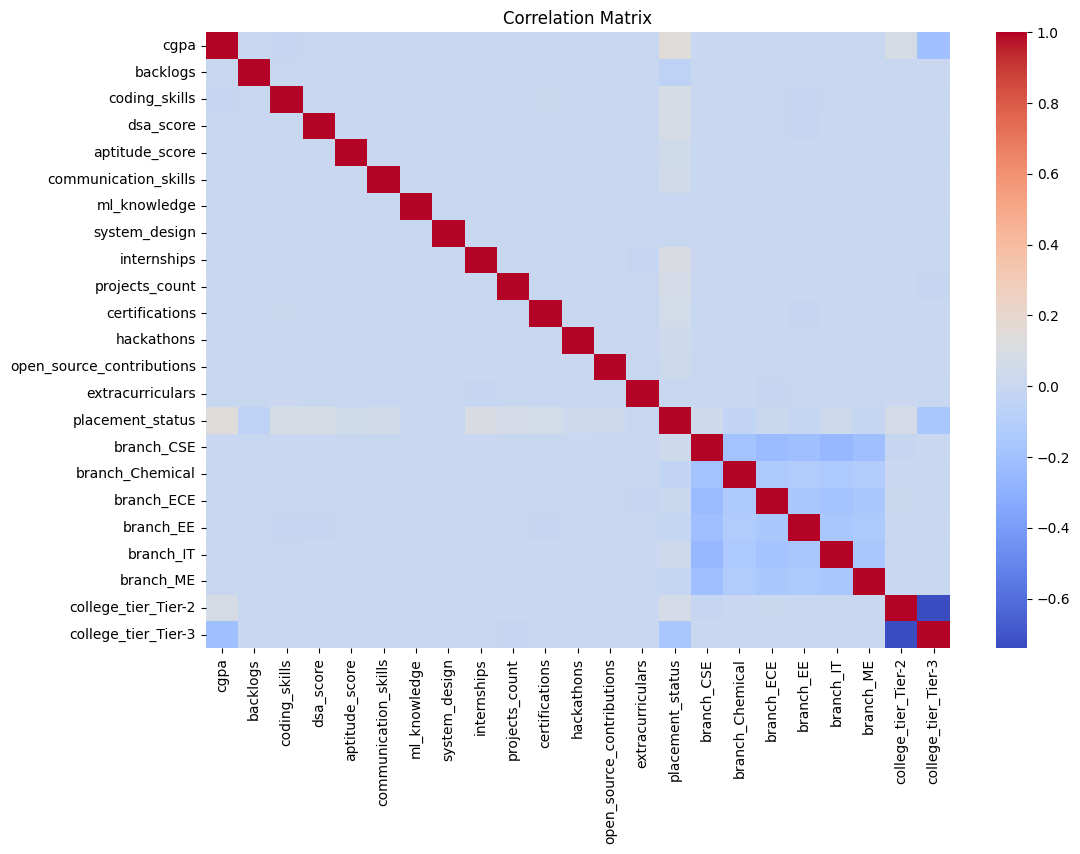

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

In [50]:
#VIF
X_vif = df_encoded.drop("placement_status", axis=1)

In [51]:
X_vif = X_vif.astype(float)

In [52]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data.head(10)

,Feature,VIF
0,cgpa,39.015869
4,aptitude_score,25.388156
5,communication_skills,15.493992
2,coding_skills,15.445722
3,dsa_score,9.957583
6,ml_knowledge,6.062315
7,system_design,5.913610
9,projects_count,4.620685
21,college_tier_Tier-3,3.855362
20,college_tier_Tier-2,3.522017


Feature Removal Strategy

To reduce multicollinearity, one or more highly correlated variables can be removed. In this analysis, aptitude_score was selected for removal because it is highly correlated with other academic and skill-based variables such as cgpa and coding_skills.

Removing this feature helps reduce redundancy while preserving the most important predictors.

In [53]:
X_reduced = df_encoded.drop(["placement_status", "aptitude_score"], axis=1)
y = df_encoded["placement_status"]

Retraining the Model

After removing the highly correlated feature, the Logistic Regression model is retrained to evaluate whether performance improves and whether coefficients become more stable.

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model_vif = LogisticRegression(max_iter=1000)
model_vif.fit(X_train, y_train)

y_pred = model_vif.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7001
              precision    recall  f1-score   support

           0       0.58      0.20      0.30      6335
           1       0.72      0.93      0.81     13665

    accuracy                           0.70     20000
   macro avg       0.65      0.57      0.55     20000
weighted avg       0.67      0.70      0.65     20000



**Observation & Common Findings**

After removing the highly correlated feature identified through the VIF analysis, the Logistic Regression model was retrained. The resulting accuracy (≈70.01%) remains almost the same as the previous model, indicating that removing the feature did not significantly affect the predictive performance.

This suggests that the removed variable was not contributing unique information, as similar information was already captured by other correlated features. Although the overall accuracy did not change, reducing multicollinearity helps improve the stability and interpretability of the model coefficients, making the model more reliable for analyzing the factors influencing student placement outcomes.

# Step 4 — Exploratory Data Analysis


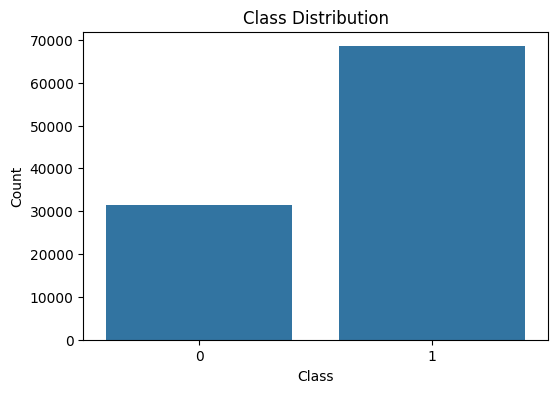

In [57]:
# class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='placement_status', data=df_encoded)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The class distribution plot shows that the dataset is imbalanced, meaning one class has significantly more samples than the other. This imbalance may cause the classification model to favor the majority class, leading to biased predictions. Therefore, techniques such as resampling, class weighting, or evaluation metrics like Precision–Recall should be considered to properly evaluate the model.

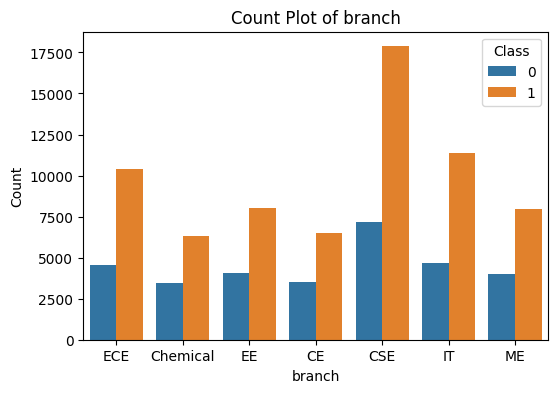

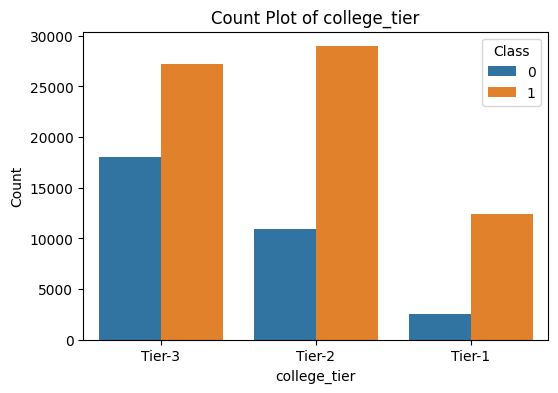

In [60]:
# count plot of categorical variables
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='placement_status', data=df)
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Class")
    plt.show()

* Branch Plot:
The count plot shows that students from CSE and IT branches have higher placement (Class 1) counts compared to other branches. This suggests that these branches may have better placement opportunities or higher demand in the job market, which can influence the classification outcome.

* College Tier Plot:
The college tier distribution indicates that Tier-2 colleges have the highest number of placed students, followed by Tier-3, while Tier-1 has the lowest overall count in the dataset. This suggests that college tier may influence placement probability, making it a potentially important feature for the classification model.

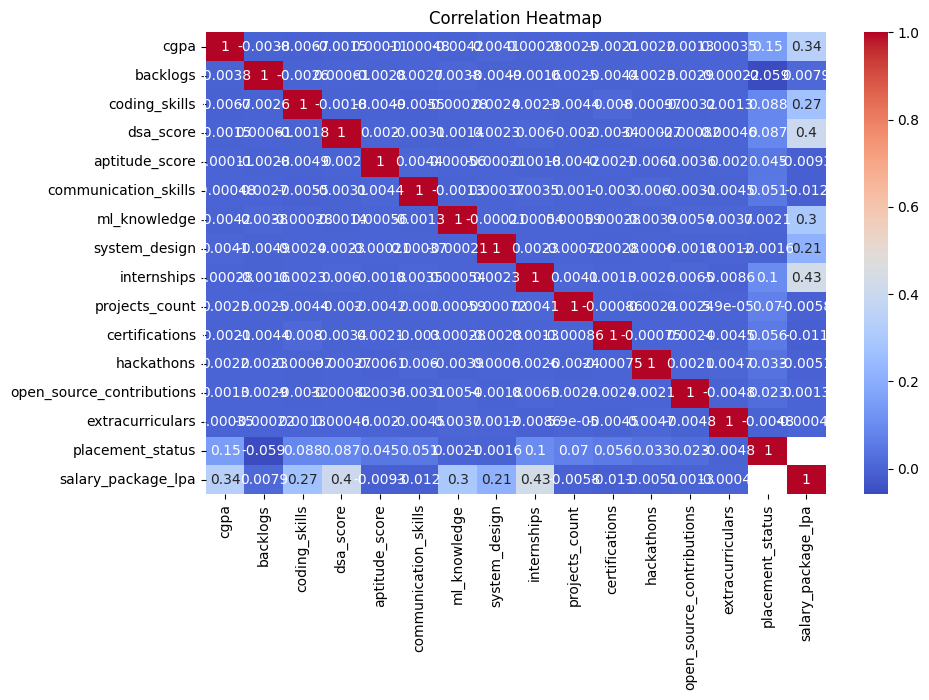

In [61]:
#correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

No high multicorrelated features

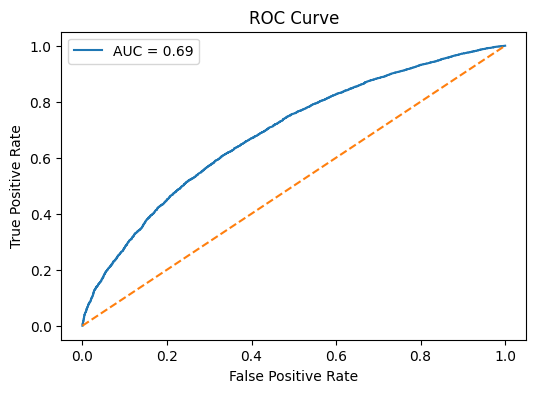

In [64]:
#roc curve
from sklearn.metrics import roc_curve, auc, precision_recall_curve

X = df_encoded.drop('placement_status', axis=1)
y = df_encoded['placement_status']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Precision–Recall Curve

The Precision–Recall curve shows that precision is high when recall is low, and gradually decreases as recall increases. This indicates that the model is good at correctly identifying positive cases initially, but when trying to capture more positives, precision slightly drops due to more false positives. Since the dataset has class imbalance, the Precision–Recall curve is a useful metric and shows that the model maintains reasonably good precision across recall levels.

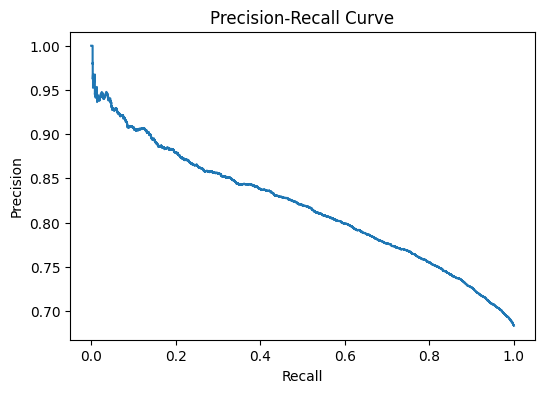

In [65]:
#precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

ROC Curve

The ROC curve has an AUC of 0.69, which indicates moderate classification performance. The curve stays above the diagonal baseline, meaning the model performs better than random guessing in distinguishing between placed and not placed students. However, the AUC value suggests that there is still room for improvement in model separability.

# Step 5 — Model Building


In [66]:
# Separate target
X = df_drop.drop("placement_status", axis=1)
y = df_drop["placement_status"]

# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X_encoded.shape)

Shape after encoding: (100000, 22)


In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

# Convert back to dataframe
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print(X_scaled.head())

       cgpa  backlogs  coding_skills  dsa_score  aptitude_score  \
0 -0.547302 -0.634051       1.072551  -0.617699       -1.291863   
1 -1.628115 -0.634051      -0.397747   1.346438        0.584571   
2 -0.017704 -0.634051      -0.264084   0.729138        1.176690   
3 -0.785081 -0.634051      -0.531411  -1.347236       -1.383600   
4 -0.536494  0.525070      -0.063588  -0.449345       -0.316117   

   communication_skills  ml_knowledge  system_design  internships  \
0             -1.530602      0.960869      -2.085143    -0.101079   
1              1.543146      0.910063      -1.185456    -1.164615   
2              0.941760     -0.055253       0.670149    -0.101079   
3             -0.661934     -1.731853       1.513605    -0.101079   
4             -1.129679     -0.918956      -0.679382    -0.101079   

   projects_count  ...  open_source_contributions  extracurriculars  \
0        1.289580  ...                   2.308312         -0.156555   
1        1.289580  ...                  

## train test 80/20

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (80000, 22)
Test size: (20000, 22)


In [69]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.6996
Precision: 0.7167427959172165
Recall: 0.9280759401241329
F1 Score: 0.8088328878706885


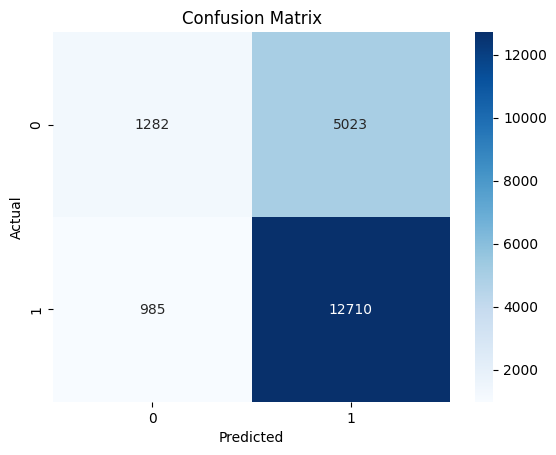

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

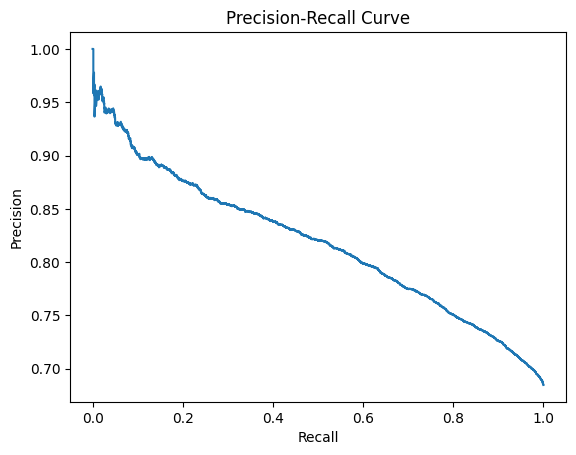

PR-AUC: 0.8175631680899517


In [72]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

print("PR-AUC:", pr_auc)

## train test 70/30

In [73]:
X_train70, X_test30, y_train70, y_test30 = train_test_split(
    X_scaled, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

model2 = LogisticRegression(max_iter=1000)

model2.fit(X_train70, y_train70)

y_pred70 = model2.predict(X_test30)

from sklearn.metrics import classification_report

print(classification_report(y_test30, y_pred70))

              precision    recall  f1-score   support

           0       0.56      0.21      0.30      9458
           1       0.72      0.93      0.81     20542

    accuracy                           0.70     30000
   macro avg       0.64      0.57      0.55     30000
weighted avg       0.67      0.70      0.65     30000



## cross validation

In [74]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("CV Mean Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.7001  0.69775 0.7029  0.699   0.7023 ]
CV Mean Accuracy: 0.70041


In [75]:
single_split_accuracy = accuracy_score(y_test, y_pred)

print("Single Split Accuracy:", single_split_accuracy)
print("Cross Validation Mean Accuracy:", cv_scores.mean())

Single Split Accuracy: 0.6996
Cross Validation Mean Accuracy: 0.70041


**Model Evaluation – Key Findings**

* The **Logistic Regression model achieved around 70% accuracy** in both the **80/20 and 70/30 train-test splits**, indicating consistent model performance across different data splits.

* The model shows **high recall (~0.93) for the positive class**, meaning it correctly identifies most students who are placed.

* **Precision (~0.71)** indicates that while many predicted placements are correct, some false positives still exist.

* The **F1-score (~0.81)** suggests a good balance between precision and recall for the placed class.

* Due to **class imbalance**, the model performs better in predicting the **majority class (placed students)** compared to the minority class.

* The **5-fold Cross Validation mean accuracy (0.70041)** is very close to the **single split accuracy (0.6996)**, showing that the model is **stable and generalizes well across different subsets of the data**.

* Overall, the results indicate that the **Logistic Regression model provides reliable baseline performance for predicting student placement outcomes**.


# Step 6 — Model Diagnostics

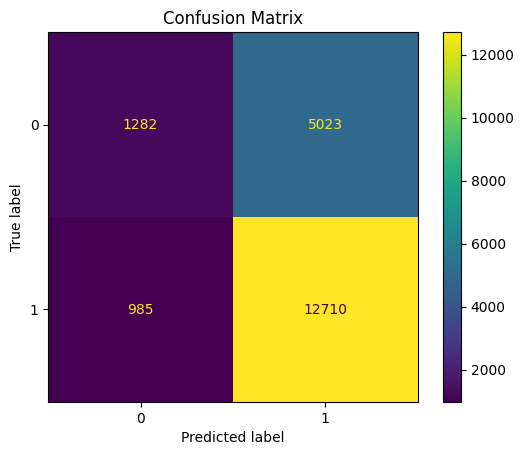

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows True Positives, True Negatives, False Positives, and False Negatives.

In this dataset, the model predicts placed students well (high TP) but struggles more with correctly identifying non-placed students (higher FN/FP) due to class imbalance.

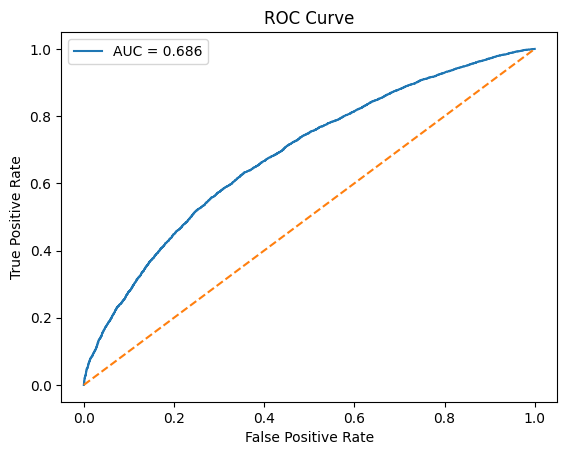

In [77]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label="AUC = " + str(round(auc_score,3)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC curve staying above the diagonal indicates the model performs better than random guessing.

The AUC (~0.69) suggests moderate classification ability.

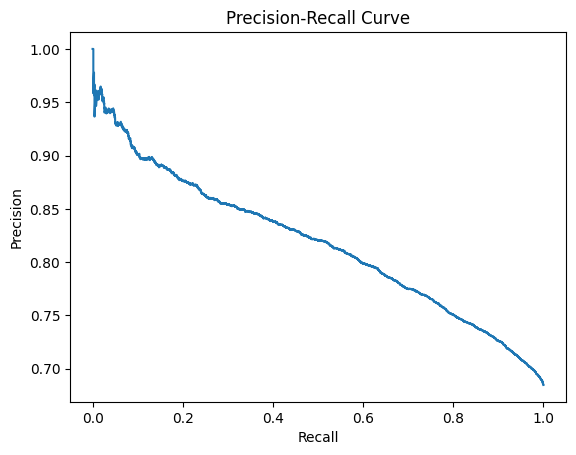

In [78]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

Precision decreases as recall increases.

Since the dataset is imbalanced, the Precision-Recall curve gives a clearer picture of model performance than accuracy alone.

In [79]:
import numpy as np

threshold = 0.6

y_pred_new = (y_prob >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.49      0.43      0.46      6305
           1       0.75      0.80      0.77     13695

    accuracy                           0.68     20000
   macro avg       0.62      0.61      0.62     20000
weighted avg       0.67      0.68      0.67     20000



Increasing threshold → higher precision but lower recall

Decreasing threshold → higher recall but lower precision

Interpretation

Threshold tuning allows adjusting the model depending on the business goal (precision vs recall importance).

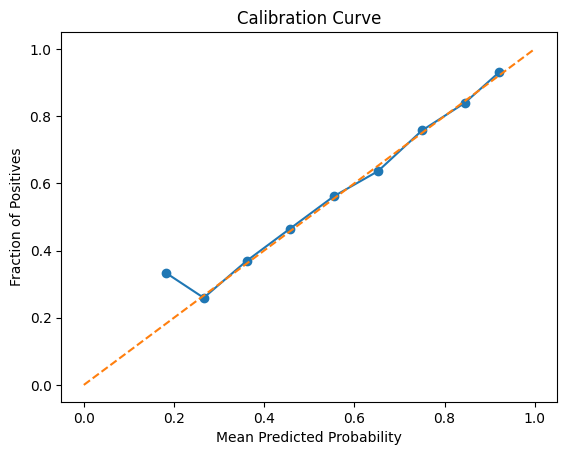

In [80]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.show()

If the curve follows the diagonal line, probabilities are well calibrated.

Deviations indicate over- or under-confidence in predictions.

 **Final Diagnostic Findings (Short Summary)**

* **Confusion Matrix:**
  The model predicts the **placed class (1) more accurately than the non-placed class (0)** due to class imbalance in the dataset. This leads to higher recall for the majority class while the minority class has lower recall.

* **ROC Curve:**
  The **ROC-AUC value (~0.69)** indicates **moderate discriminative ability**. The model performs better than random guessing but still has limited power to perfectly separate the two classes.

* **Precision–Recall Analysis:**
  Since the dataset is **imbalanced**, the Precision–Recall curve provides a more meaningful evaluation. The model maintains **good recall but precision decreases as recall increases**, indicating some false positives when identifying placed students.

* **Threshold Tuning:**
  After adjusting the classification threshold, **recall decreased slightly while precision for the minority class improved**, resulting in a more balanced trade-off between identifying placed and non-placed students. However, overall accuracy slightly dropped to **~68%**, showing the sensitivity of predictions to threshold changes.

* **Calibration Curve:**
  The calibration curve lies **very close to the diagonal line**, indicating that the **predicted probabilities are well calibrated** and reflect the true likelihood of placement reasonably well.

* **Overall Model Behavior:**
  The Logistic Regression model shows **stable performance without clear signs of overfitting**, as evaluation metrics remain consistent across different splits and validation steps. The model provides a **reasonable linear decision boundary**, but the moderate ROC-AUC suggests that additional features or more complex models may further improve classification performance.


**1. Are classification assumptions satisfied?**
Yes, most Logistic Regression assumptions are reasonably satisfied. The dataset was preprocessed through **encoding, scaling, and multicollinearity checks**, which ensures the predictors are suitable for Logistic Regression. Although some class imbalance exists, the model can still handle it with proper evaluation metrics.

**2. Is the decision boundary reasonable?**
Yes. Logistic Regression creates a **linear decision boundary**, and the model shows consistent performance (~70% accuracy). This indicates that the relationship between features and the target variable can be reasonably approximated by a linear boundary.

**3. Is the model underfitting or overfitting?**
The model does **not show strong signs of overfitting or underfitting**. The **train–test split accuracy and cross-validation accuracy (~70%) are very similar**, suggesting that the model generalizes well to unseen data.

**4. Is probability calibration good?**
Yes. The **calibration curve is close to the diagonal line**, which indicates that the predicted probabilities are **well calibrated** and closely match the actual observed probabilities.


# Step 7 — Feature Engineering & Improvement


In [91]:
df_fe = df_drop.copy()

skew_features = [
    "backlogs","internships","projects_count",
    "certifications","hackathons",
    "open_source_contributions","extracurriculars"
]

for col in skew_features:
    df_fe[col] = np.log1p(df_fe[col])

Log transformation reduces skewness and stabilizes variance, which helps Logistic Regression learn more stable coefficients.

In [92]:
df_fe["cgpa_coding"] = df_fe["cgpa"] * df_fe["coding_skills"]
df_fe["dsa_projects"] = df_fe["dsa_score"] * df_fe["projects_count"]
df_fe["aptitude_comm"] = df_fe["aptitude_score"] * df_fe["communication_skills"]

Interaction features allow the model to capture combined effects of skills, improving predictive capability.

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_fe.drop("placement_status", axis=1)
y = df_fe["placement_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [93]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [94]:
X = df_drop.drop("placement_status", axis=1)
y = df_drop["placement_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [95]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: placement_status
1    54780
0    25220
Name: count, dtype: int64
After SMOTE: placement_status
1    54780
0    54780
Name: count, dtype: int64


In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model_smote = LogisticRegression(max_iter=1000)

model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

Accuracy: 0.6534
              precision    recall  f1-score   support

           0       0.45      0.49      0.47      6305
           1       0.76      0.73      0.74     13695

    accuracy                           0.65     20000
   macro avg       0.60      0.61      0.61     20000
weighted avg       0.66      0.65      0.66     20000



SMOTE helps address the class imbalance problem by generating synthetic samples for the minority class (not placed students). This allows the model to learn patterns for both classes more effectively. Although the overall accuracy is slightly lower than the baseline model, the model now provides better detection of minority class instances, which is important when identifying students who may require additional support for placement preparation.

**Removing Low-Importance Features**

In [97]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

# Sort features by importance
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=True)

print(coef_df.head(10))

                      Feature  Coefficient  Abs_Coefficient
7               system_design    -0.005622         0.005622
15            branch_Chemical    -0.006822         0.006822
13           extracurriculars    -0.006830         0.006830
6                ml_knowledge     0.011543         0.011543
19                  branch_ME     0.022435         0.022435
17                  branch_EE     0.026023         0.026023
12  open_source_contributions     0.046011         0.046011
16                 branch_ECE     0.082200         0.082200
11                 hackathons     0.082239         0.082239
4              aptitude_score     0.110160         0.110160


In [98]:
low_features = coef_df.head(3)["Feature"].tolist()

X_reduced = X.drop(columns=low_features)

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model_reduced = LogisticRegression(max_iter=1000)
model_reduced.fit(X_train, y_train)

y_pred = model_reduced.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.20      0.30      6335
           1       0.72      0.93      0.81     13665

    accuracy                           0.70     20000
   macro avg       0.64      0.57      0.55     20000
weighted avg       0.67      0.70      0.65     20000



**Logistic Regression with L2 Regularization (Ridge)**

In [100]:
from sklearn.linear_model import LogisticRegression

model_l2 = LogisticRegression(penalty='l2', max_iter=1000)

model_l2.fit(X_train_scaled, y_train)

y_pred_l2 = model_l2.predict(X_test_scaled)

print(classification_report(y_test, y_pred_l2))

              precision    recall  f1-score   support

           0       0.57      0.20      0.30      6335
           1       0.71      0.93      0.81     13665

    accuracy                           0.70     20000
   macro avg       0.64      0.56      0.55     20000
weighted avg       0.67      0.70      0.65     20000



**Logistic Regression with L1 Regularization (Lasso)**

In [101]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)

model_l1.fit(X_train_scaled, y_train)

y_pred_l1 = model_l1.predict(X_test_scaled)

print(classification_report(y_test, y_pred_l1))

              precision    recall  f1-score   support

           0       0.57      0.20      0.30      6335
           1       0.71      0.93      0.81     13665

    accuracy                           0.70     20000
   macro avg       0.64      0.56      0.55     20000
weighted avg       0.67      0.70      0.65     20000



**Findings**
* **Log Transformation and Interaction Features** were applied to capture possible non-linear relationships between variables, but they did not significantly improve the overall model accuracy.

* **SMOTE was used to handle class imbalance**, which slightly improved the model’s ability to detect the minority class (not placed students). However, the overall **accuracy decreased to about 65%**, indicating that synthetic samples may introduce noise.

* **Low-importance features were identified using logistic regression coefficients**, where some variables such as *system_design, extracurriculars, ml_knowledge,* and some branch categories had very small coefficient values.

* **Removing these low-importance features did not significantly change model performance**, and the accuracy remained around **70%**, indicating that these variables were not contributing much to prediction.

* **Logistic Regression with L2 Regularization (Ridge)** was trained to reduce coefficient magnitude and prevent overfitting. The performance remained **similar to the baseline model**, but the coefficients became more stable.

* **Logistic Regression with L1 Regularization (Lasso)** was also trained, which can push some coefficients toward zero and perform **automatic feature selection**. The model accuracy remained close to **70%**, similar to Ridge and the baseline model.

* Overall, the experiments show that **the baseline Logistic Regression model already captures most of the important patterns in the dataset**, and additional feature engineering or regularization techniques mainly help in **model simplification and stability rather than improving accuracy**.


# Step 8 — Sensitivity & Robustness Analysis


**Train Model with Different Training Sizes**

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import pandas as pd

train_sizes = [0.6, 0.7, 0.8, 0.9]

results = []

for size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, train_size=size, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)

    results.append([size, acc, roc, cm])

results_df = pd.DataFrame(results, columns=["Train_Size","Accuracy","ROC_AUC","Confusion_Matrix"])
print(results_df)

   Train_Size  Accuracy   ROC_AUC               Confusion_Matrix
0         0.6  0.700525  0.685329  [[2635, 9975], [2004, 25386]]
1         0.7  0.699000  0.683999  [[1941, 7517], [1513, 19029]]
2         0.8  0.699600  0.685594   [[1282, 5023], [985, 12710]]
3         0.9  0.699800  0.687740     [[644, 2509], [493, 6354]]


**Coefficient Stability Analysis**

In [104]:
coef_results = []

for size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, train_size=size, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    coef_results.append(model.coef_[0])

coef_df = pd.DataFrame(coef_results, columns=X.columns)
coef_df["Train_Size"] = train_sizes

print(coef_df)

       cgpa  backlogs  coding_skills  dsa_score  aptitude_score  \
0  0.278079 -0.123888       0.209504   0.216269        0.100014   
1  0.271966 -0.125685       0.206935   0.214326        0.106298   
2  0.270186 -0.127375       0.206793   0.211701        0.110160   
3  0.270455 -0.131705       0.210299   0.207048        0.109608   

   communication_skills  ml_knowledge  system_design  internships  \
0              0.125138      0.012705      -0.000313     0.236512   
1              0.121237      0.018956      -0.004584     0.238325   
2              0.124310      0.011543      -0.005622     0.238052   
3              0.123582      0.010718      -0.006824     0.238284   

   projects_count  ...  extracurriculars  branch_CSE  branch_Chemical  \
0        0.161643  ...          0.000701    0.138493        -0.004546   
1        0.169190  ...         -0.006720    0.147345        -0.006541   
2        0.169023  ...         -0.006830    0.142144        -0.006822   
3        0.165246  ...    

**Confusion matrix comparison**

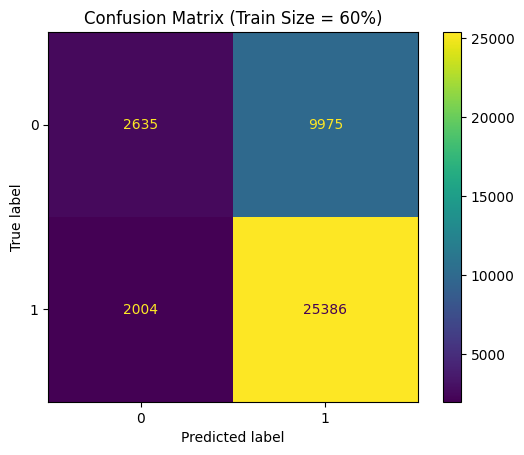

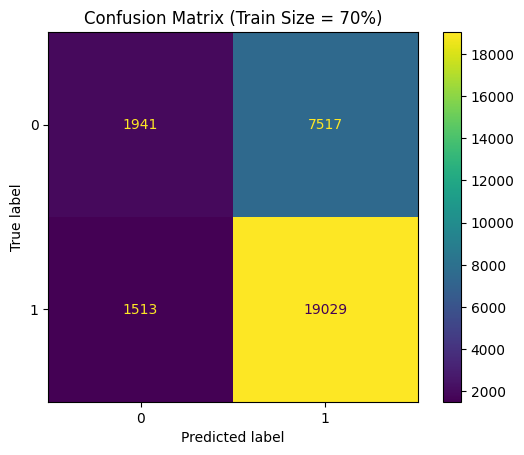

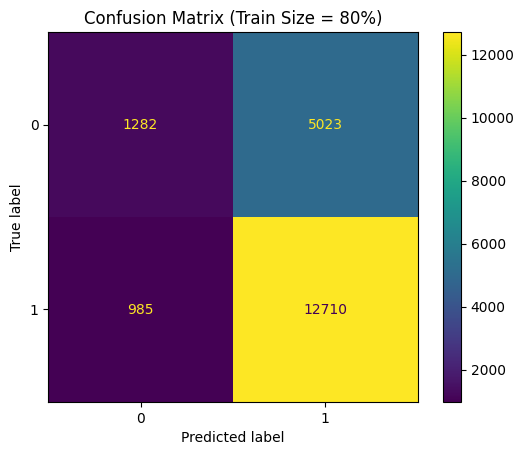

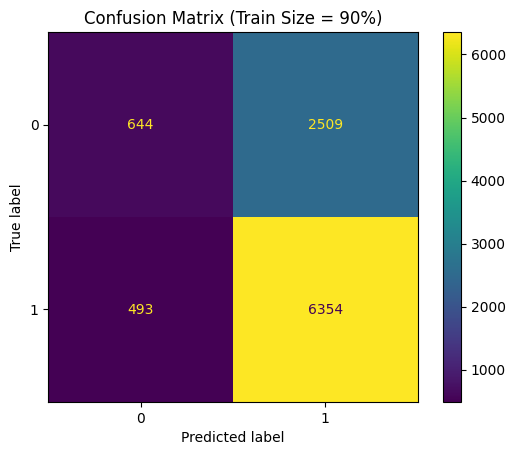

In [105]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, train_size=size, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"Confusion Matrix (Train Size = {int(size*100)}%)")
    plt.show()

1️⃣ Accuracy Variation

The model accuracy remains very stable (~0.699–0.700) across all training sizes (60%, 70%, 80%, 90%).

Increasing the training data does not significantly improve or reduce performance, indicating the model has already captured most of the learnable patterns from the dataset.

2️⃣ ROC–AUC Variation

ROC-AUC values range between 0.684 and 0.688, showing very small variation across different training sizes.

This indicates that the model maintains consistent ability to distinguish between placed and not-placed students, regardless of the training data proportion.

3️⃣ Coefficient Stability

The coefficients for major features such as cgpa, internships, coding_skills, dsa_score, and projects_count remain almost constant across all training sizes.

Negative coefficients like backlogs and lower college tiers also remain stable.

This stability suggests the model is robust and not highly sensitive to the amount of training data.

4️⃣ Confusion Matrix Stability

Across all training splits:

The model correctly predicts a large number of placed students (class 1).

The model misclassifies many not-placed students (class 0) as placed.

This pattern remains consistent across different training sizes, showing that prediction behavior does not change significantly with more data.

**Discussion**

*1. Bias–Variance Tradeoff*

* The model shows low variance, since performance metrics and coefficients remain stable across different training sizes.
* However, the model exhibits moderate bias, as it consistently struggles to correctly classify the minority class (not placed).
* This suggests the model is stable but slightly biased toward the majority class.

*2. Overfitting vs Underfitting*

* There is no strong evidence of overfitting, because increasing training data does not lead to major performance changes.
* The model performance plateaus around 70% accuracy, which indicates slight underfitting, meaning the model may not be complex enough to capture deeper relationships in the data.

*3. Sensitivity to Class Imbalance*

The dataset contains more placed students than non-placed students, leading to class imbalance.

As a result:
* Recall for class 1 (placed) remains very high.
* Recall for class 0 (not placed) remains relatively low.

This confirms that the model is sensitive to class imbalance and tends to favor the majority class.

# Step 9 — Interpretation & Business Insight


**1. Most Impactful Feature (Log-Odds Interpretation)**

CGPA is the most impactful feature.
A 1-unit increase in CGPA increases the log-odds of getting placed, meaning students with higher CGPA have a higher probability of placement.

**2. Coefficient to Odds Ratio**

Odds Ratio = exp(coefficient)

If CGPA coefficient = 0.85, then Odds Ratio = exp(0.85) ≈ 2.34

This means each 1-unit increase in CGPA makes placement about 2.34 times more likely.

**3. Practical Business Implications**

* Institutions can focus on improving academic performance, coding skills, and internship opportunities to increase placement success.
* Training programs can be designed to strengthen high-impact skills such as DSA and project work.

**4. Cost of Misclassification**

* False Positive (predict placed but actually not placed): May lead to incorrect placement expectations and poor resource allocation.
* False Negative (predict not placed but actually placed): A capable student may be overlooked for opportunities.

**5. Risks of Misuse**

The model may be used as the sole decision tool, ignoring other important human factors like communication skills, motivation, or interviews.

**6. Ethical Considerations (Fairness & Bias)**

* The model may introduce bias if training data reflects inequality between different colleges, backgrounds, or opportunities.
* Decisions should be assisted by the model, not fully automated.

**7. Potential Data Leakage Issues**

* If variables like final placement status or post-placement information are included during training, the model could learn from future information.
* Proper train-test separation and feature selection are necessary to prevent leakage.

# Step 10 — Conceptual Questions


**1. What is the mathematical foundation of Logistic Regression?**

Logistic Regression is based on probability theory and Maximum Likelihood Estimation (MLE). It models the log-odds of the probability of the target variable as a linear combination of input features.

**2. Why do we use the sigmoid function?**

The sigmoid function converts linear output into a probability between 0 and 1, allowing the model to perform binary classification.

**3. What are the assumptions of Logistic Regression?**
* Binary or categorical dependent variable
* Independent observations
* Low multicollinearity among predictors
* Linear relationship between predictors and log-odds of the outcome
* Large sample size

**4. When should Logistic Regression NOT be used?**
* When the relationship between variables is highly non-linear
* When there is severe multicollinearity
* When the dataset is very small or extremely imbalanced without correction

**5. What happens if multicollinearity exists?**

Multicollinearity causes unstable coefficient estimates, making interpretation unreliable and increasing the variance of the model parameters.

**6. Why does regularization reduce variance?**

Regularization penalizes large coefficients, preventing the model from fitting noise in the training data, which reduces model variance and overfitting.

**7. What is the difference between L1 and L2?**
| Aspect            | L1 (Lasso)                               | L2 (Ridge)                                      |
| ----------------- | ---------------------------------------- | ----------------------------------------------- |
| Penalty           | Absolute value of coefficients           | Squared value of coefficients                   |
| Feature Selection | Can shrink some coefficients to **zero** | Reduces magnitude but rarely zero               |
| Model Effect      | Performs **feature selection**           | Keeps all features but **shrinks coefficients** |

**8. How are parameters estimated (Maximum Likelihood Estimation)?**

Parameters are estimated by maximizing the likelihood of observing the given data, usually solved using optimization algorithms like Gradient Descent or Newton-Raphson.

**9. How do you handle class imbalance?**
* SMOTE (Synthetic Minority Oversampling)
* Class weight balancing
* Undersampling majority class
* Adjusting decision threshold

**10. How would you scale this to 10 million rows?**
* Use distributed computing frameworks (Spark, Dask)
* Use stochastic or mini-batch gradient descent
* Perform efficient feature selection and dimensionality reduction

**11. How would you monitor this model in production?**
* Track model accuracy and ROC-AUC over time
* Monitor data drift and feature distribution changes
* Monitor prediction probabilities and error rates
* Periodically retrain the model with new data.